In [1]:
from finagg.fred.api import CategorySeries, SeriesObservations,SeriesCategories,Tags
import pandas as pd
so = SeriesObservations()
sc = SeriesCategories()
ret= []

def get_series(eventid):
    metadata = sc.get(eventid)
    eclass = metadata.iloc[-1]['name']
    df = so.get(eventid )[['series_id', 'value', 'date']]
    df.columns= ['event', 'actual', 'datetime']
    df['eclass'] = eclass
    df['datetime'] = pd.to_datetime(df.datetime)
    return df


In [2]:
usdjpy = get_series('DEXJPUS')
audusd = get_series('DEXUSAL')
sp500 = get_series('SP500')


In [5]:
sp500d = sp500.set_index('datetime')['actual']
usdjpyd = usdjpy.set_index('datetime')['actual']
audusdd = audusd.set_index('datetime')['actual']

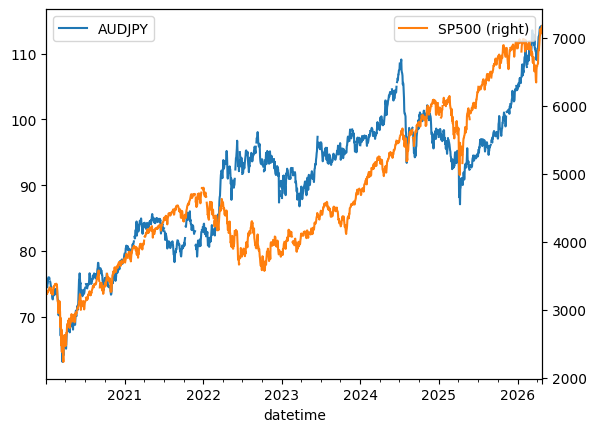

In [16]:
s1 = (usdjpyd * audusdd)
s1_after = s1[s1.index > pd.Timestamp('2020-01-01')]

sp500_after = sp500d[sp500d.index > pd.Timestamp('2020-01-01')]

ax = s1_after.plot(label='AUDJPY')
sp500_after.plot(ax=ax, secondary_y=True, label='SP500')

ax.legend(loc='upper left')
ax.right_ax.legend(loc='upper right')
